In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
from genflows.models.unet3d import UNet3D
from genflows.methods.flow_matching import FlowMatching
from sample import load_cond_stats, normalize_cond, load_method, samples_to_binary, make_cond_grid

In [ ]:
#export variable CUDA_VISIBLE_DEVICES
os.environ['CUDA_VISIBLE_DEVICES'] = '2'  # Change to your GPU ID(s) or leave empty for CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load normalization stats
cond_min, cond_max = load_cond_stats()
param_names = ['height', 'radius', 'aspect_ratio', 'azimuth', 'ntg']
print("Conditioning ranges (from training):")
for i, name in enumerate(param_names):
    print(f"  {name}: [{cond_min[i]:.2f}, {cond_max[i]:.2f}]")

fm_arrays = []
methods = {}
checkpoints = {
    # 'diffusion': 'checkpoints/diffusion.pt',
    'flow_matching': 'checkpoints/flow_matching.pt',
    # 'rectified_flow': 'checkpoints/rectified_flow.pt',
    # 'rectified_flow_bwd': 'checkpoints/rectified_flow_bwd.pt',
    # 'rectified_flow_bidir': 'checkpoints/rectified_flow_bidir.pt',
    # 'rectified_flow_rand': 'checkpoints/rectified_flow_rand.pt',
    # 'meanflow_std': 'checkpoints/meanflow_std.pt',
    # 'meanflow_embed': 'checkpoints/meanflow_embed.pt',
}

for name, path in checkpoints.items():
    if os.path.exists(path):
        print(f"Loading {name} from {path}")
        methods[name] = load_method(name, path, device)
    else:
        print(f"WARNING: {path} not found, skipping {name}")

# Create conditional parameter space for sampling
n_samples = 10
# raw_cond = make_cond_grid(cond_min, cond_max, n_samples)
raw_cond = np.hstack([
    np.linspace(cond_min[0], cond_max[0], n_samples).reshape(-1,1),  # height
    np.full((n_samples,1), 0.5*cond_min[1] + 0.5*cond_max[1]),       # radius
    np.full((n_samples,1), 0.5*cond_min[2] + 0.5*cond_max[2]),       # aspect_ratio
    np.full((n_samples,1), 0.5*cond_min[3] + 0.5*cond_max[3]),       # azimuth
    np.full((n_samples,1), 0.5*cond_min[4] + 0.5*cond_max[4]),       # ntg
])
raw_cond = np.vstack([raw_cond, np.hstack([
    np.full((n_samples,1), 0.5*cond_min[0] + 0.5*cond_max[0]),       # height
    np.linspace(cond_min[1], cond_max[1], n_samples).reshape(-1,1),  # radius
    np.full((n_samples,1), 0.5*cond_min[2] + 0.5*cond_max[2]),       # aspect_ratio
    np.full((n_samples,1), 0.5*cond_min[3] + 0.5*cond_max[3]),       # azimuth
    np.full((n_samples,1), 0.5*cond_min[4] + 0.5*cond_max[4]),       # ntg
])])
raw_cond = np.vstack([raw_cond, np.hstack([
    np.full((n_samples,1), 0.5*cond_min[0] + 0.5*cond_max[0]),       # height
    np.full((n_samples,1), 0.5*cond_min[1] + 0.5*cond_max[1]),       # radius
    np.linspace(cond_min[2], cond_max[2], n_samples).reshape(-1,1),  # aspect_ratio
    np.full((n_samples,1), 0.5*cond_min[3] + 0.5*cond_max[3]),       # azimuth
    np.full((n_samples,1), 0.5*cond_min[4] + 0.5*cond_max[4]),       # ntg
])])
raw_cond = np.vstack([raw_cond, np.hstack([
    np.full((n_samples,1), 0.5*cond_min[0] + 0.5*cond_max[0]),       # height
    np.full((n_samples,1), 0.5*cond_min[1] + 0.5*cond_max[1]),       # radius
    np.full((n_samples,1), 0.5*cond_min[2] + 0.5*cond_max[2]),       # aspect_ratio
    np.linspace(cond_min[3], cond_max[3], n_samples).reshape(-1,1),  # azimuth
    np.full((n_samples,1), 0.5*cond_min[4] + 0.5*cond_max[4]),       # ntg
])])
raw_cond = np.vstack([raw_cond, np.hstack([
    np.full((n_samples,1), 0.5*cond_min[0] + 0.5*cond_max[0]),       # height
    np.full((n_samples,1), 0.5*cond_min[1] + 0.5*cond_max[1]),       # radius
    np.full((n_samples,1), 0.5*cond_min[2] + 0.5*cond_max[2]),       # aspect_ratio
    np.full((n_samples,1), 0.5*cond_min[3] + 0.5*cond_max[3]),       # azimuth
    np.linspace(cond_min[4], cond_max[4], n_samples).reshape(-1,1),  # ntg
])])
cond_norm = normalize_cond(raw_cond, cond_min, cond_max)
cond_tensor = torch.from_numpy(cond_norm).to(device)

shape = (5*n_samples, 1, 50, 50, 50)
step_counts = [1, 5, 10, 50]

print(f"\nGenerating {n_samples} samples per method per step count...")
print(f"Conditioning values (raw):")
param_strings = []
for i in range(n_samples):
    param_strings.append(', '.join(f"{param_names[j]}={raw_cond[i, j]:.2f}" for j in range(len(param_names))))
    print(f"  Sample {i}: {param_strings}")

for n_steps in step_counts:
    print(f"\n--- {n_steps} steps ---")

    if 'diffusion' in methods:
        for sampler in ['ddpm', 'ddim']:
            t0 = time.time()
            samples = methods['diffusion'].sample(
                shape, device, cond=cond_tensor, cfg_scale=3.0,
                n_steps=n_steps, sampler=sampler
            )
            elapsed = time.time() - t0
            binary = samples_to_binary(samples)
            tag = sampler.upper()
            print(f"  {tag}  {n_steps:>4} steps: {elapsed:.2f}s")
            np.save(f"results/samples_{sampler}_{n_steps}steps.npy", binary.cpu().numpy())

    for name in ['flow_matching', 'rectified_flow', 'rectified_flow_bwd',
                    'rectified_flow_bidir', 'rectified_flow_rand',
                    'meanflow_std', 'meanflow_embed']:
        if name not in methods:
            continue
        t0 = time.time()
        samples = methods[name].sample(
            shape, device, cond=cond_tensor, cfg_scale=3.0, n_steps=n_steps
        )
        elapsed = time.time() - t0
        binary = samples_to_binary(samples)
        short = name.upper().replace('_', '-')
        print(f"  {short:<15} {n_steps:>4} steps: {elapsed:.2f}s")
        fm_arrays.append(binary.cpu().numpy())

print("\nDone! Samples saved to 'results/' as .npy files.")
print("Each file has shape (N, 1, 50, 50, 50) with binary {0, 1} values.")

In [2]:
# fm_arrays = [np.load(f"samples_flow_matching_{i}steps.npy") for i in [1,5,10,50,100]]

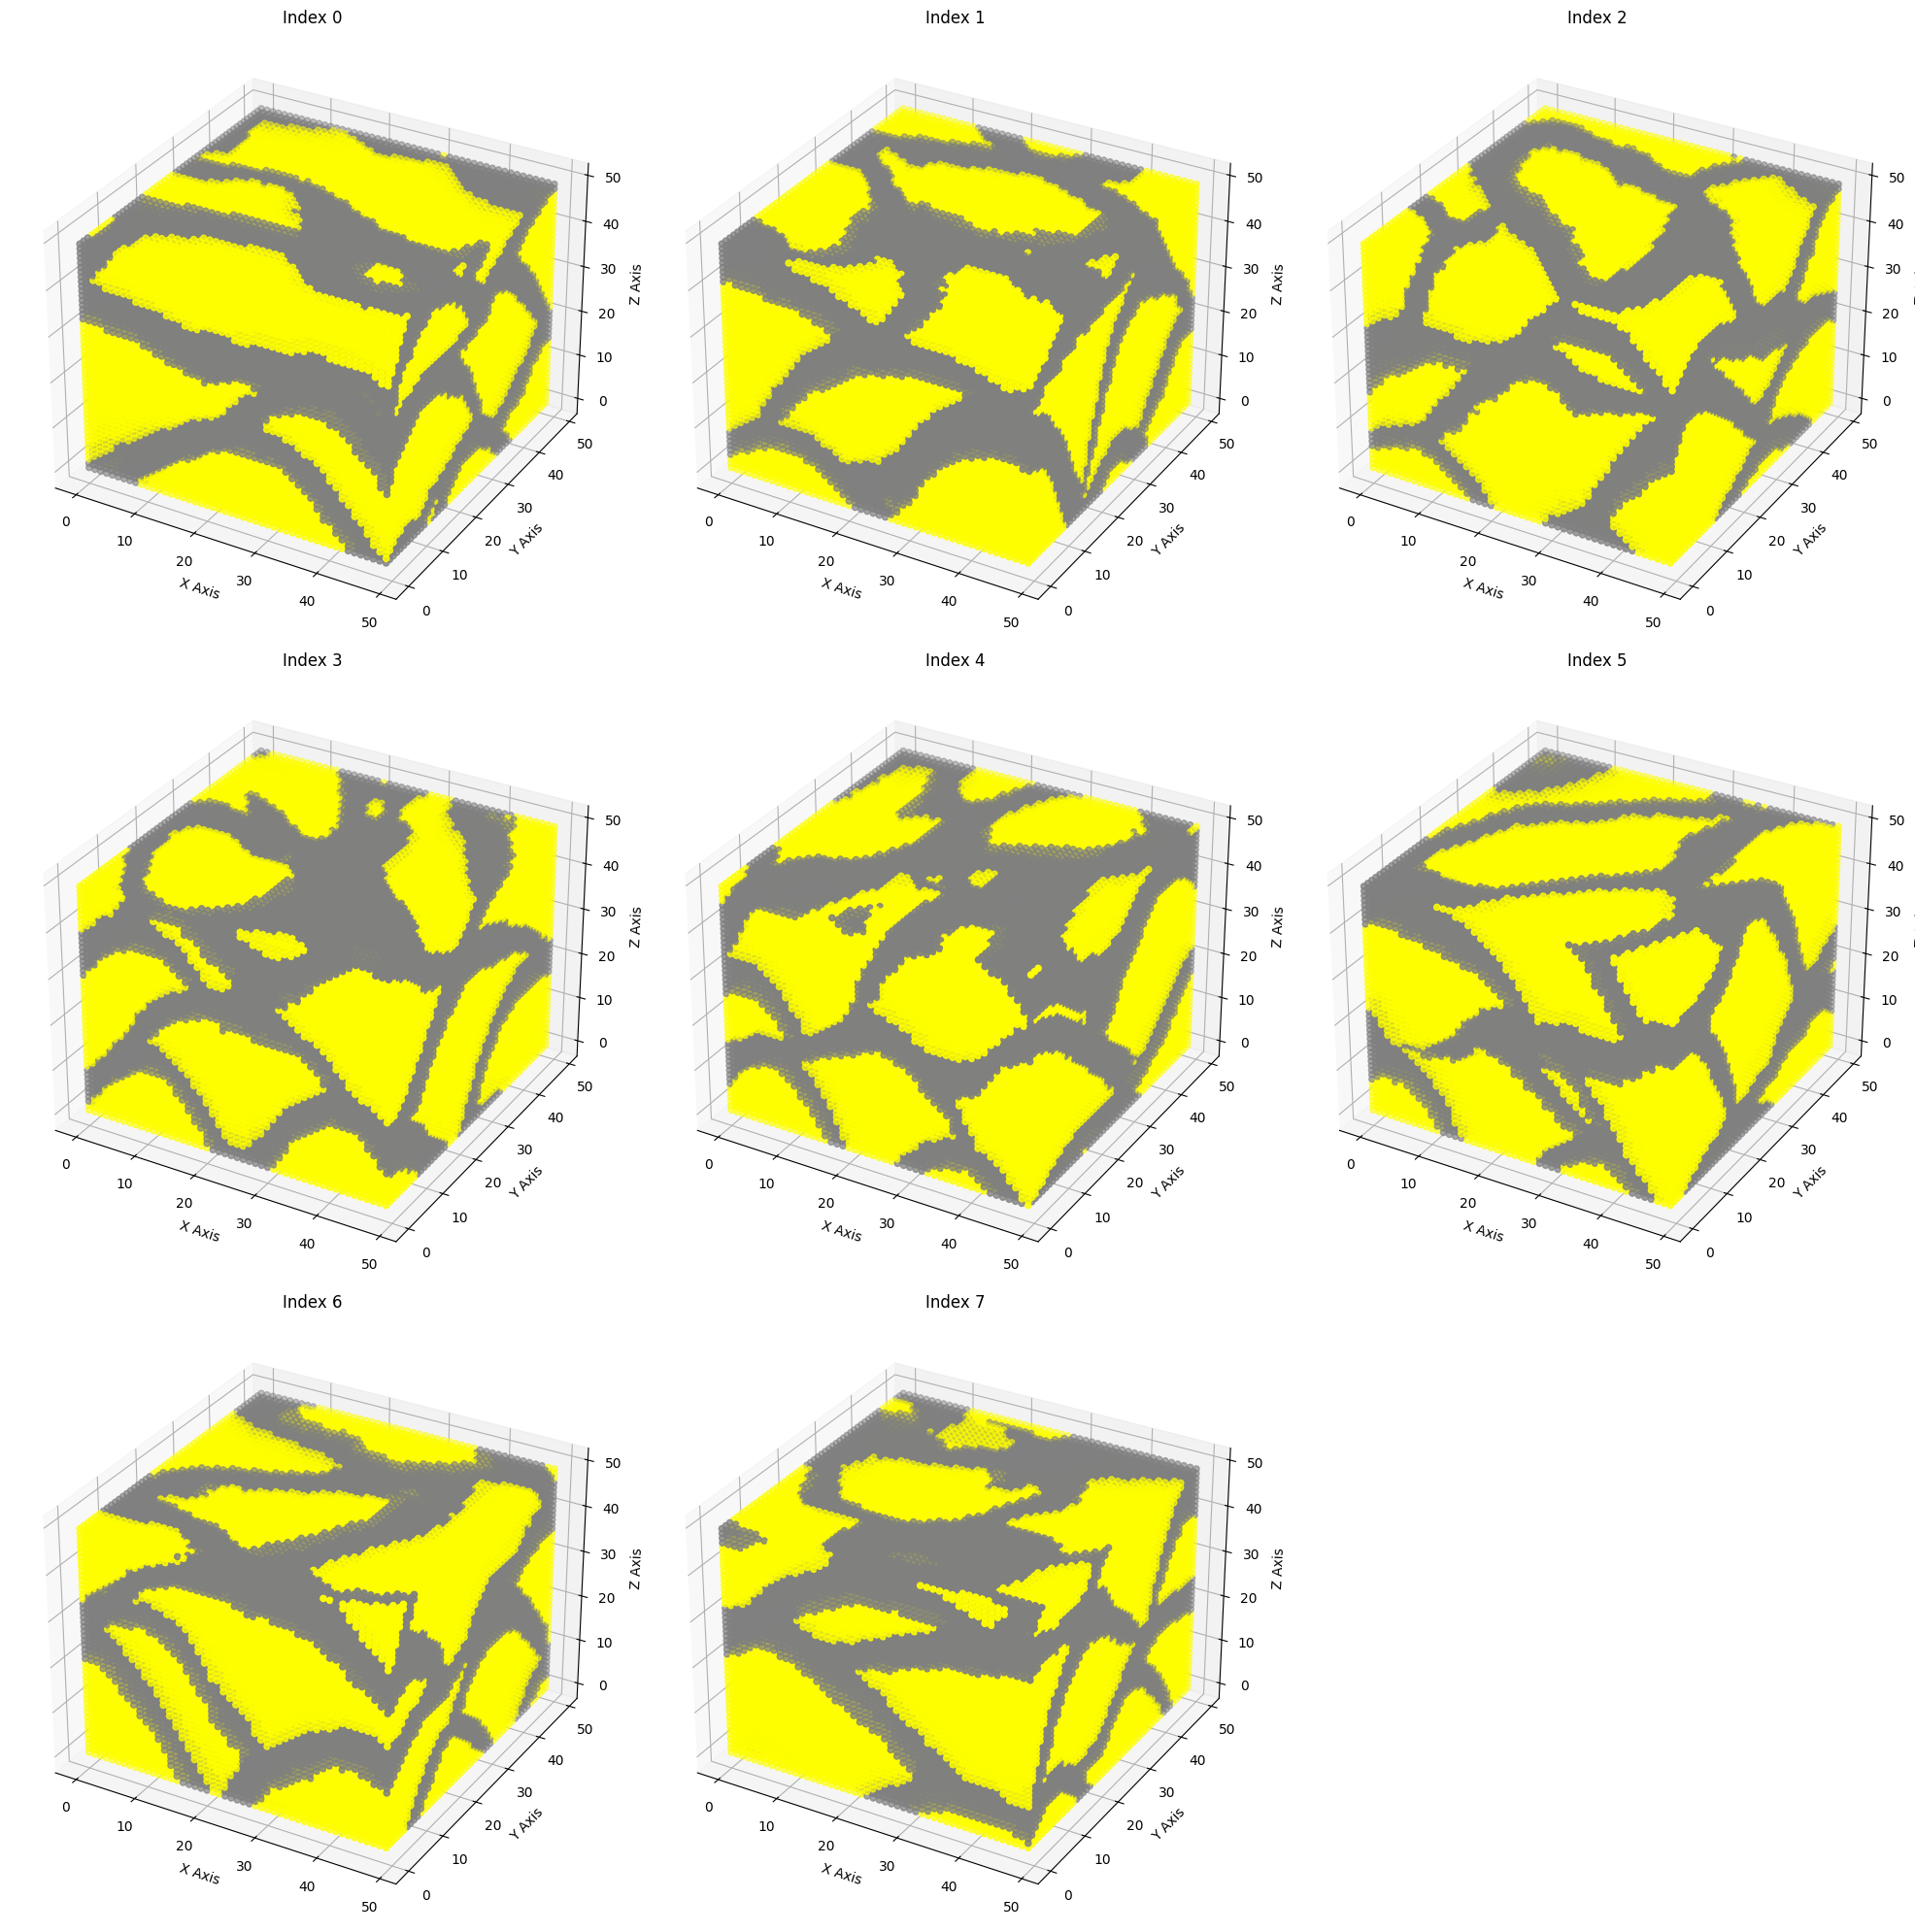

In [3]:
# fig = plt.figure(figsize=(20, 20))

# custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

# for idx in range(8):
#     ax = fig.add_subplot(3, 3, idx + 1, projection='3d')  # 3x3 grid of subplots
    
#     # Extract x, y, and z coordinates from the numpy array
#     x, y, z = np.indices(fm_arrays[3][idx][0].shape)
#     values = fm_arrays[3][idx][0].flatten()
    
#     # Flatten the numpy array and use it as the values for the 3D plot
#     ax.scatter(x.flatten(), y.flatten(), z.flatten(), c=values, cmap=custom_cmap)
    
#     ax.set_xlabel('X Axis')
#     ax.set_ylabel('Y Axis')
#     ax.set_zlabel('Z Axis')
#     ax.set_title(f'Index {idx}')

# plt.tight_layout()
# plt.show()

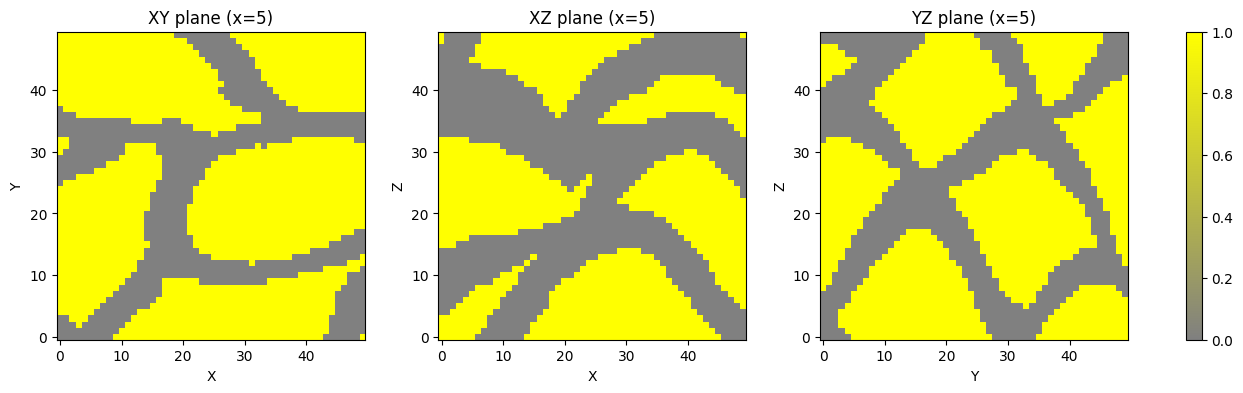

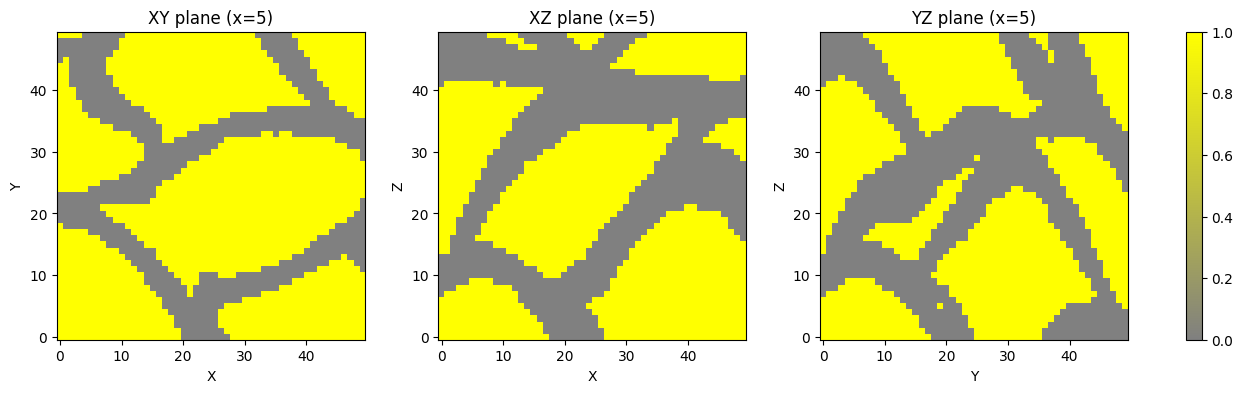

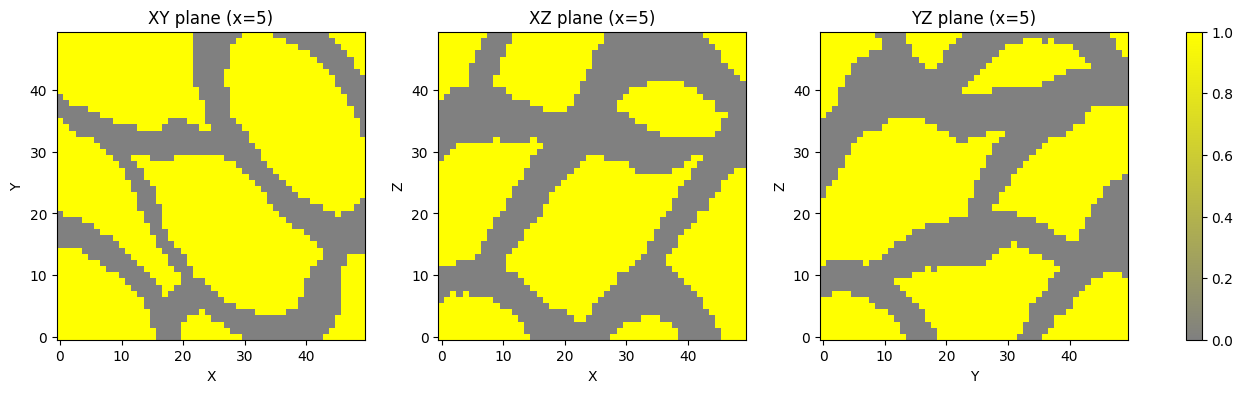

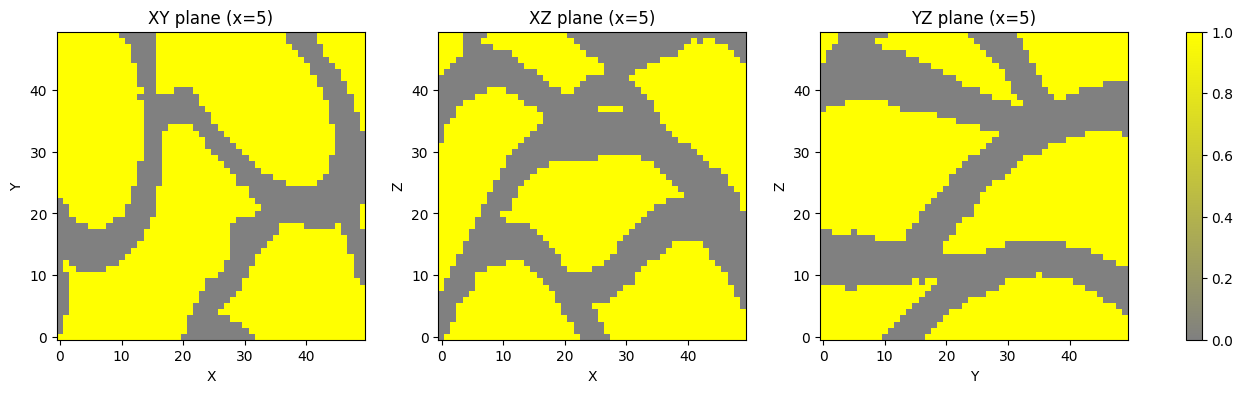

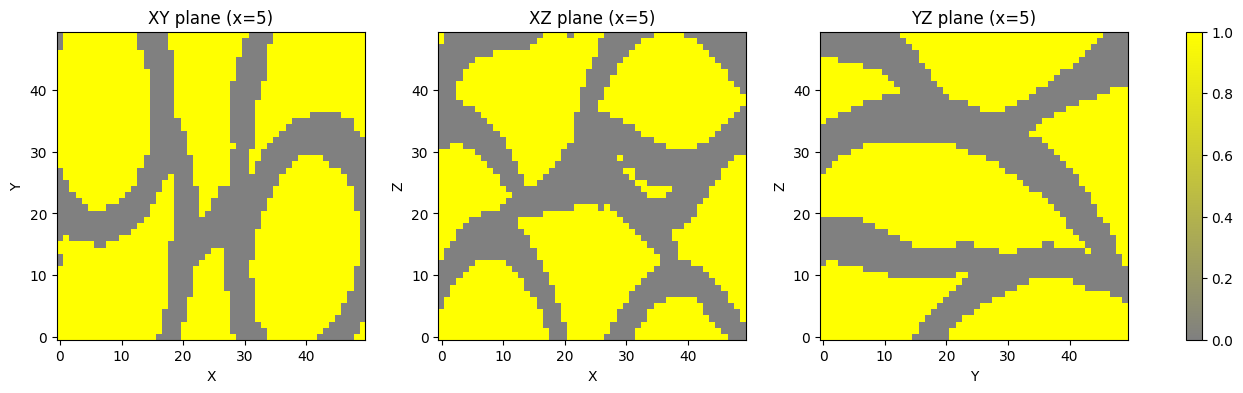

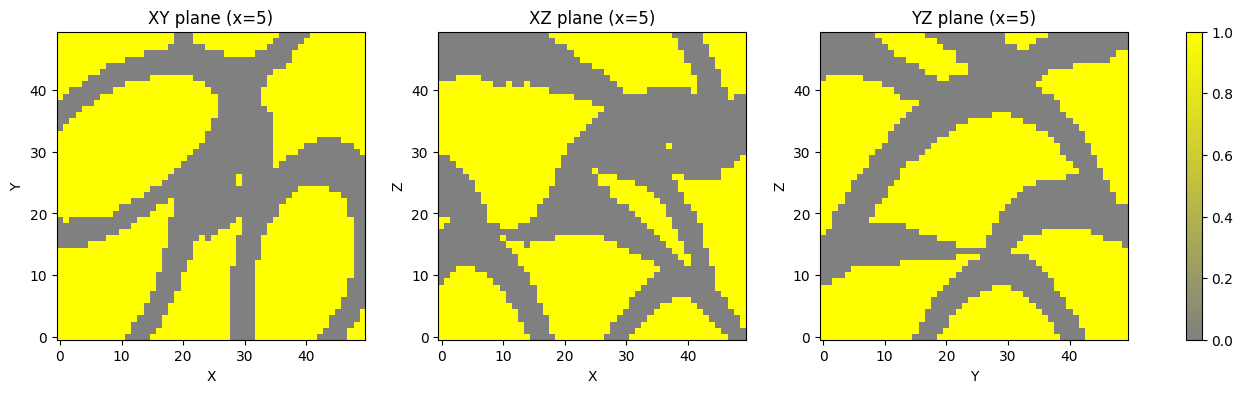

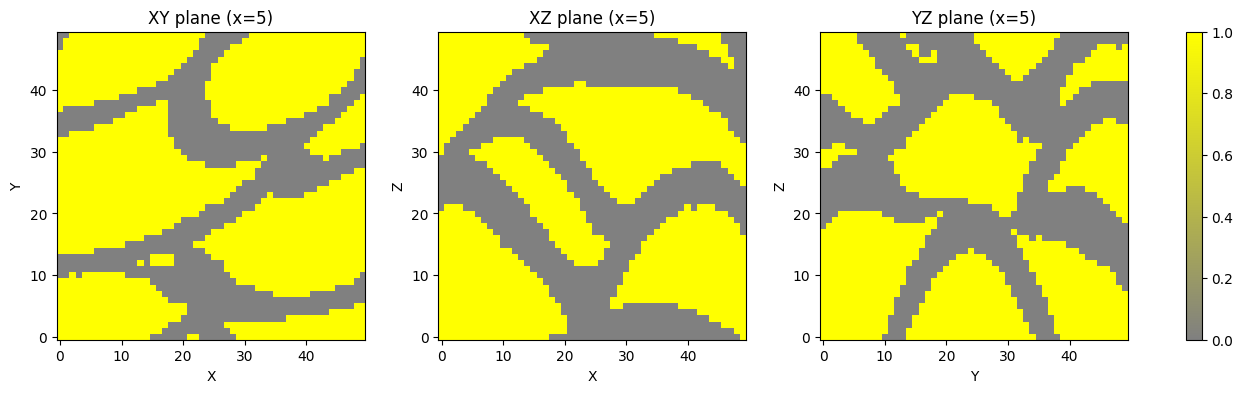

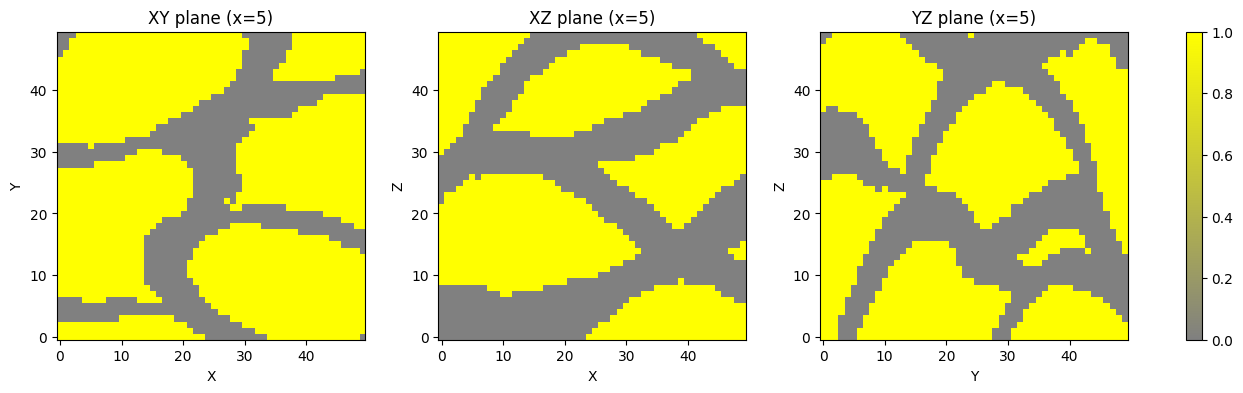

In [5]:
custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

for i in range(10):
    print(param_strings[i])

    data = fm_arrays[3][i, 0]  # shape: (X, Y, Z)

    x_slice, y_slice, z_slice = 5, 5, 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # XY plane (fixed Z)
    axes[0].imshow(data[:, :, z_slice].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'XY plane (x={x_slice})')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    # XZ plane (fixed Y)
    axes[1].imshow(data[:, y_slice, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'XZ plane (x={x_slice})')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')

    # YZ plane (fixed X)
    axes[2].imshow(data[x_slice, :, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'YZ plane (x={x_slice})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('Z')

    plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02)
    plt.show()

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

for i in range(10,20):
    print(param_strings[i])

    data = fm_arrays[3][i, 0]  # shape: (X, Y, Z)

    x_slice, y_slice, z_slice = 5, 5, 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # XY plane (fixed Z)
    axes[0].imshow(data[:, :, z_slice].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'XY plane (x={x_slice})')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    # XZ plane (fixed Y)
    axes[1].imshow(data[:, y_slice, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'XZ plane (x={x_slice})')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')

    # YZ plane (fixed X)
    axes[2].imshow(data[x_slice, :, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'YZ plane (x={x_slice})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('Z')

    plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02)
    plt.show()

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

for i in range(20,30):
    print(param_strings[i])

    data = fm_arrays[3][i, 0]  # shape: (X, Y, Z)

    x_slice, y_slice, z_slice = 5, 5, 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # XY plane (fixed Z)
    axes[0].imshow(data[:, :, z_slice].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'XY plane (x={x_slice})')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    # XZ plane (fixed Y)
    axes[1].imshow(data[:, y_slice, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'XZ plane (x={x_slice})')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')

    # YZ plane (fixed X)
    axes[2].imshow(data[x_slice, :, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'YZ plane (x={x_slice})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('Z')

    plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02)
    plt.show()

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

for i in range(30,40):
    print(param_strings[i])

    data = fm_arrays[3][i, 0]  # shape: (X, Y, Z)

    x_slice, y_slice, z_slice = 5, 5, 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # XY plane (fixed Z)
    axes[0].imshow(data[:, :, z_slice].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'XY plane (x={x_slice})')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    # XZ plane (fixed Y)
    axes[1].imshow(data[:, y_slice, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'XZ plane (x={x_slice})')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')

    # YZ plane (fixed X)
    axes[2].imshow(data[x_slice, :, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'YZ plane (x={x_slice})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('Z')

    plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02)
    plt.show()

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list('grey_yellow', ['grey', 'yellow'])

for i in range(40,50):
    print(param_strings[i])

    data = fm_arrays[3][i, 0]  # shape: (X, Y, Z)

    x_slice, y_slice, z_slice = 5, 5, 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # XY plane (fixed Z)
    axes[0].imshow(data[:, :, z_slice].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'XY plane (x={x_slice})')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    # XZ plane (fixed Y)
    axes[1].imshow(data[:, y_slice, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'XZ plane (x={x_slice})')
    axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')

    # YZ plane (fixed X)
    axes[2].imshow(data[x_slice, :, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'YZ plane (x={x_slice})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('Z')

    plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02)
    plt.show()